# Notebook 02 — QR Detection & Perspective Rectification

**Pipeline:** Adaptive Classical Vision Pipeline for Cut-Edge Detection  
**Step 2:** QR visual detection → exterior corner extraction → affine transform → perspective rectification

**Input:** Preprocessed images from `outputs/01_preprocessed/`  
**Output:**
- Rectified images saved to `outputs/02_rectified/`
- Calibration data saved to `outputs/02_rectified/calibration.json`

**Note:** QR codes are too blurry to decode so we detect them visually using
edge density and white ring filters (adapted from Miguel's pipeline).
The three QR exterior corners form a right triangle with legs of 800 mm.

## 1. Imports and configuration

In [1]:
!pip install opencv-python numpy matplotlib

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
PREPROCESSED_DIR = Path("outputs/01_preprocessed")  # input from NB01
IMAGES_DIR       = Path("data/images")               # original images for colour output
OUTPUT_DIR       = Path("outputs/02_rectified")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Physical reference (mm) ────────────────────────────────────────────────
# TL exterior corner → (0,         0        )
# TR exterior corner → (QR_LEG_MM, 0        )
# BR exterior corner → (QR_LEG_MM, QR_LEG_MM)
QR_LEG_MM = 800.0

# ── Visual QR detection parameters ────────────────────────────────────────
MIN_SIZE_RATIO   = 0.006
MAX_SIZE_RATIO   = 0.08
MIN_WHITE_RING   = 0.45
MIN_EDGE_DENSITY = 0.08

print(f"Preprocessed dir : {PREPROCESSED_DIR.resolve()}")
print(f"Output dir       : {OUTPUT_DIR.resolve()}")

Preprocessed dir : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\01_preprocessed
Output dir       : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\02_rectified


## 2. Visual QR detection

Detects QR candidates by looking for small square regions with:
1. High internal edge density (QR pattern)
2. A white ring surrounding the region (printed on white table)

In [4]:
def _merge_close_candidates(candidates, dist_factor=1.5):
    merged = []
    for c in sorted(candidates, key=lambda z: z.get('score', 0), reverse=True):
        cx, cy = c['center']
        duplicated = False
        for m in merged:
            mx, my = m['center']
            max_dist = dist_factor * max(c.get('size', 20), m.get('size', 20))
            if np.hypot(cx - mx, cy - my) < max_dist:
                duplicated = True
                break
        if not duplicated:
            merged.append(c)
    return merged


def detect_qr_candidates(img_gray: np.ndarray) -> list:
    """
    Detect QR code candidates from a preprocessed grayscale image.
    Reads the already-preprocessed image from NB01 (no extra blur/CLAHE needed).
    """
    H, W = img_gray.shape
    diag = np.hypot(H, W)
    min_size = int(diag * MIN_SIZE_RATIO)
    max_size = int(diag * MAX_SIZE_RATIO)

    # Multiple binarisation strategies for robustness
    binaries = [
        cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                              cv2.THRESH_BINARY_INV, 21, 5),
        cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                              cv2.THRESH_BINARY_INV, 21, 7),
        cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    ]

    candidates = []
    for binary in binaries:
        cnts, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in cnts:
            x, y, w, h = cv2.boundingRect(cnt)
            size = max(w, h)
            if size < min_size or size > max_size:
                continue
            aspect = w / (h + 1e-6)
            if not (0.55 <= aspect <= 1.8):
                continue
            if cv2.contourArea(cnt) / (w * h + 1e-6) < 0.05:
                continue

            # White ring check
            pad = int(size * 1.4)
            x1 = max(0, x - pad); y1 = max(0, y - pad)
            x2 = min(W, x + w + pad); y2 = min(H, y + h + pad)
            ring = img_gray[y1:y2, x1:x2].copy()
            ring[max(0, y-y1):min(y+h, y2)-y1,
                 max(0, x-x1):min(x+w, x2)-x1] = 0
            vals = ring[ring > 0]
            white_ring = np.mean(vals > 135) if vals.size else 0
            if white_ring < MIN_WHITE_RING:
                continue

            # Internal edge density check
            roi = img_gray[y:y+h, x:x+w]
            edge_density = np.mean(cv2.Canny(roi, 40, 120) > 0)
            if edge_density < MIN_EDGE_DENSITY:
                continue

            score = white_ring + edge_density - abs(aspect - 1.0) * 0.5
            candidates.append({
                'center': (float(x + w / 2), float(y + h / 2)),
                'size':   float(size),
                'bbox':   (x, y, w, h),
                'score':  float(score)
            })

    candidates = sorted(candidates, key=lambda c: c.get('score', 0), reverse=True)
    return _merge_close_candidates(candidates)

## 3. QR ordering and exterior corner extraction

- **TL QR** → top-left corner: `(x, y)`
- **TR QR** → top-right corner: `(x+w, y)`
- **BR QR** → bot-right corner: `(x+w, y+h)`

In [5]:
def order_qr_candidates(candidates: list) -> dict:
    if len(candidates) < 3:
        raise ValueError(f"Need at least 3 QR candidates, found {len(candidates)}")
    top3    = candidates[:3]
    centers = np.array([c['center'] for c in top3], dtype=np.float32)
    sums    = centers[:, 0] + centers[:, 1]
    tl_idx  = int(np.argmin(sums))
    br_idx  = int(np.argmax(sums))
    tr_idx  = [i for i in range(3) if i != tl_idx and i != br_idx][0]
    return {'TL': top3[tl_idx], 'TR': top3[tr_idx], 'BR': top3[br_idx]}


def extract_exterior_corners(ordered_qrs: dict) -> np.ndarray:
    x, y, w, h = ordered_qrs['TL']['bbox']
    tl = (float(x),     float(y)    )
    x, y, w, h = ordered_qrs['TR']['bbox']
    tr = (float(x + w), float(y)    )
    x, y, w, h = ordered_qrs['BR']['bbox']
    br = (float(x + w), float(y + h))
    return np.array([tl, tr, br], dtype=np.float32)

## 4. Affine transform and rectification

In [6]:
def compute_homography(corners_px: np.ndarray, qr_leg_mm: float = QR_LEG_MM) -> tuple:
    """
    Compute affine transform that corrects perspective while keeping
    the output image in pixel coordinates.
    Returns H (3x3) and px_per_mm scale factor.
    """
    dx_px     = np.linalg.norm(corners_px[1] - corners_px[0])  # TL → TR
    dy_px     = np.linalg.norm(corners_px[2] - corners_px[1])  # TR → BR
    px_per_mm = ((dx_px + dy_px) / 2.0) / qr_leg_mm

    tl     = corners_px[0]
    leg_px = qr_leg_mm * px_per_mm

    dst_pts = np.array([
        [tl[0],           tl[1]          ],
        [tl[0] + leg_px,  tl[1]          ],
        [tl[0] + leg_px,  tl[1] + leg_px ],
    ], dtype=np.float32)

    A = cv2.getAffineTransform(corners_px, dst_pts)
    H = np.vstack([A, [0, 0, 1]]).astype(np.float32)

    return H, float(px_per_mm)


def rectify_image(img: np.ndarray, H: np.ndarray) -> np.ndarray:
    h, w = img.shape[:2]
    return cv2.warpPerspective(img, H, (w, h))

## 5. Full pipeline per image

Reads the preprocessed grayscale image from NB01 for QR detection,
and applies the same rectification transform to both the grayscale
and the original colour image.

In [7]:
def process_image(image_name: str) -> dict | None:
    # Load preprocessed grayscale from NB01
    pre_path = PREPROCESSED_DIR / image_name
    img_gray = cv2.imread(str(pre_path), cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        print(f"  [SKIP] Could not load preprocessed image: {image_name}")
        return None

    # Detect QR on preprocessed image
    candidates = detect_qr_candidates(img_gray)
    if len(candidates) < 3:
        print(f"  [WARN] {image_name}: only {len(candidates)} QR candidate(s) — skipping")
        return None

    ordered      = order_qr_candidates(candidates)
    corners      = extract_exterior_corners(ordered)
    H, px_per_mm = compute_homography(corners)

    # Rectify the preprocessed grayscale image and save
    rect_gray = rectify_image(img_gray, H)
    cv2.imwrite(str(OUTPUT_DIR / image_name), rect_gray)

    return {
        'image_name': image_name,
        'H':          H.tolist(),
        'px_per_mm':  px_per_mm,
        'corners_px': corners.tolist(),
        'qr_labels':  {k: list(v['bbox']) for k, v in ordered.items()}
    }

In [8]:
image_names = [
    p.name for p in sorted(PREPROCESSED_DIR.glob("*.jpg"))
    + sorted(PREPROCESSED_DIR.glob("*.png"))
]
print(f"Found {len(image_names)} preprocessed images\n")

calibration_data = {}
for name in image_names:
    result = process_image(name)
    if result is not None:
        calibration_data[name] = result
        print(f"  [OK] {name:30s}  px/mm = {result['px_per_mm']:.4f}")

print(f"\nProcessed {len(calibration_data)} / {len(image_names)} images successfully")

# Save calibration for use by NB03, NB05, NB06
calib_path = OUTPUT_DIR / "calibration.json"
with open(calib_path, "w") as f:
    json.dump(calibration_data, f, indent=2)
print(f"Calibration saved to {calib_path}")

Found 24 preprocessed images

  [OK] Multimedia_31.jpg               px/mm = 1.6044
  [OK] Multimedia_32.jpg               px/mm = 1.6164
  [OK] Multimedia_33.jpg               px/mm = 1.5501
  [OK] Multimedia_34.jpg               px/mm = 1.5793
  [OK] Multimedia_35.jpg               px/mm = 0.1180
  [OK] Multimedia_36.jpg               px/mm = 0.3899
  [OK] Multimedia_37.jpg               px/mm = 1.0028
  [OK] Multimedia_38.jpg               px/mm = 0.7753
  [OK] Multimedia_39.jpg               px/mm = 1.4264
  [OK] Multimedia_40.jpg               px/mm = 1.5404
  [OK] Multimedia_41.jpg               px/mm = 0.9725
  [OK] Multimedia_42.jpg               px/mm = 0.7546
  [OK] Multimedia_43.jpg               px/mm = 0.4690
  [OK] Multimedia_44.jpg               px/mm = 0.4461
  [OK] Multimedia_45.jpg               px/mm = 1.6586
  [OK] Multimedia_46.jpg               px/mm = 0.7107
  [OK] Multimedia_47.jpg               px/mm = 1.6758
  [OK] Multimedia_48.jpg               px/mm = 1.730

## 6. Visual inspection

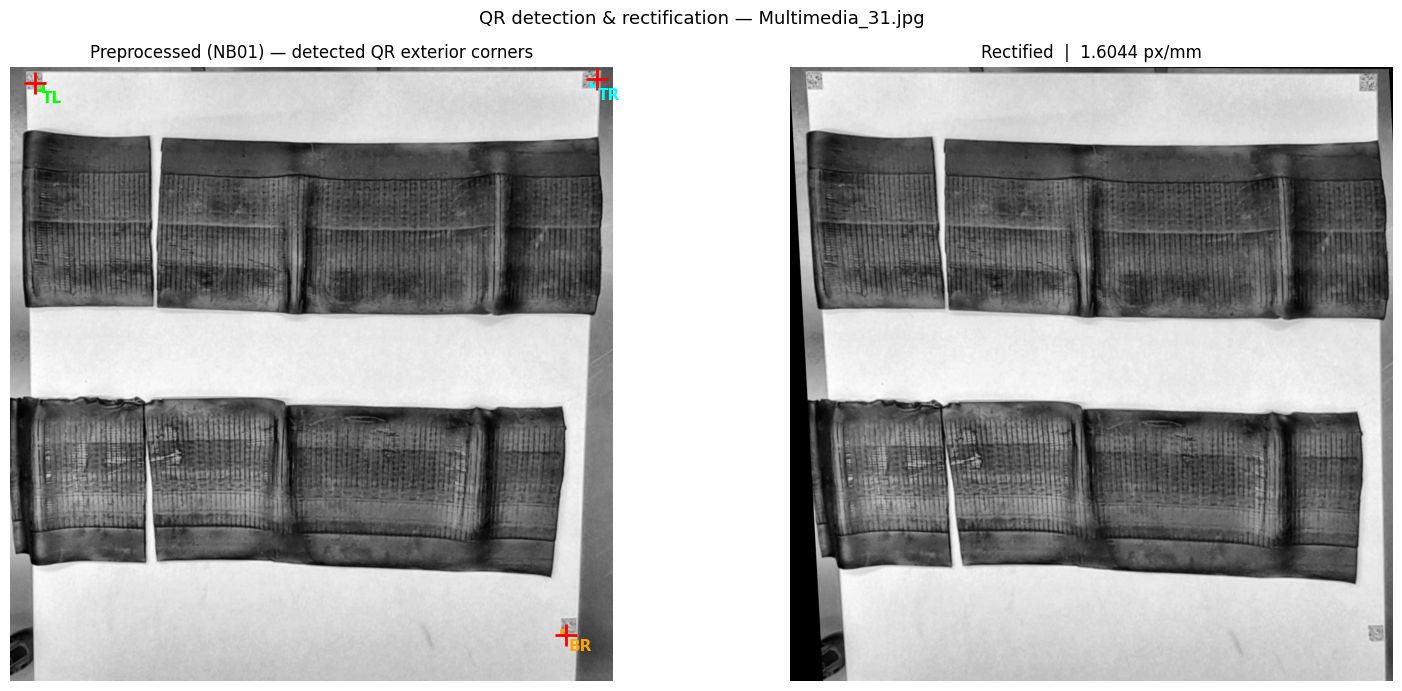

In [9]:
def visualize_result(image_name: str):
    calib    = calibration_data[image_name]
    original = cv2.imread(str(PREPROCESSED_DIR / image_name), cv2.IMREAD_GRAYSCALE)
    rectified = cv2.imread(str(OUTPUT_DIR / image_name), cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"QR detection & rectification — {image_name}", fontsize=13)

    axes[0].imshow(original, cmap='gray')
    axes[0].set_title("Preprocessed (NB01) — detected QR exterior corners")
    colors = {'TL': 'lime', 'TR': 'cyan', 'BR': 'orange'}
    for label, bbox in calib['qr_labels'].items():
        x, y, w, h = bbox
        rect = plt.Rectangle((x, y), w, h, linewidth=2,
                              edgecolor=colors[label], facecolor='none')
        axes[0].add_patch(rect)
        axes[0].annotate(label, (x, y), color=colors[label],
                         fontsize=11, fontweight='bold',
                         xytext=(5, -15), textcoords='offset points')
    for cx, cy in calib['corners_px']:
        axes[0].plot(cx, cy, 'r+', markersize=16, markeredgewidth=2)
    axes[0].axis('off')

    axes[1].imshow(rectified, cmap='gray')
    axes[1].set_title(f"Rectified  |  {calib['px_per_mm']:.4f} px/mm")
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"check_{image_name}", dpi=120)
    plt.show()


if calibration_data:
    visualize_result(next(iter(calibration_data)))
else:
    print("No images processed — adjust detection parameters.")

## 7. px/mm scale distribution

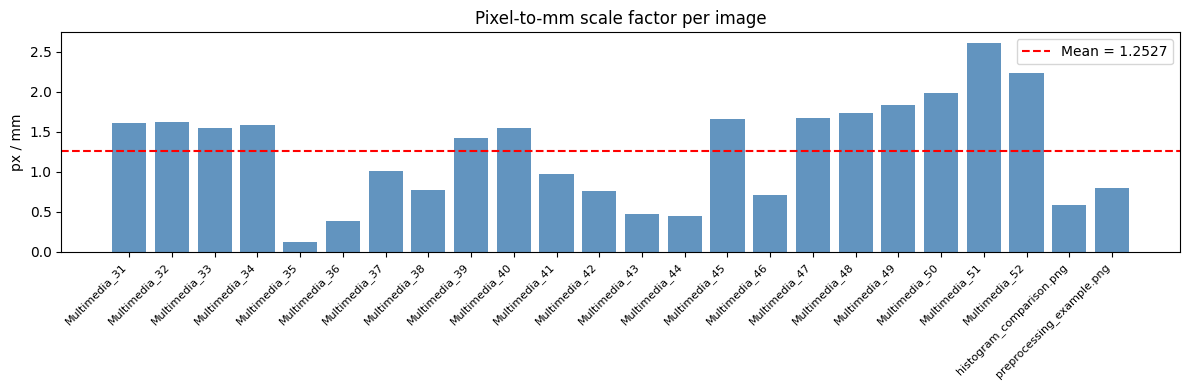

Mean  px/mm : 1.2527
Std   px/mm : 0.6351
Min   px/mm : 0.1180  (Multimedia_35.jpg)
Max   px/mm : 2.6110  (Multimedia_51.jpg)


In [10]:
if calibration_data:
    names  = list(calibration_data.keys())
    scales = [calibration_data[n]['px_per_mm'] for n in names]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(range(len(names)), scales, color='steelblue', alpha=0.85)
    ax.axhline(np.mean(scales), color='red', linestyle='--',
               label=f"Mean = {np.mean(scales):.4f}")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.replace('.jpg', '') for n in names],
                       rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('px / mm')
    ax.set_title('Pixel-to-mm scale factor per image')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'scale_distribution.png', dpi=150)
    plt.show()

    print(f"Mean  px/mm : {np.mean(scales):.4f}")
    print(f"Std   px/mm : {np.std(scales):.4f}")
    print(f"Min   px/mm : {np.min(scales):.4f}  ({names[int(np.argmin(scales))]})") 
    print(f"Max   px/mm : {np.max(scales):.4f}  ({names[int(np.argmax(scales))]})") 

## 8. Summary

| Step | Operation | Detail |
|------|-----------|--------|
| 2a | Read preprocessed image | from `outputs/01_preprocessed/` |
| 2b | Visual QR detection | edge density + white ring filter |
| 2c | QR ordering | TL / TR / BR by x+y sum |
| 2d | Exterior corner extraction | TL→(x,y)  TR→(x+w,y)  BR→(x+w,y+h) |
| 2e | Affine transform (px→px) | `cv2.getAffineTransform`, 800 mm legs |
| 2f | Perspective rectification | `cv2.warpPerspective` |

**Output folder:** `outputs/02_rectified/`  
**Calibration file:** `outputs/02_rectified/calibration.json`  
**Used by:** NB03, NB05, NB06  
**Next notebook:** `03_canny.ipynb` — reads from `outputs/02_rectified/`